# RQ5_refined


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Model  Accuracy        F1  Rank
0    LR  0.608696  0.583765   2.0
1    RF  0.695652  0.649144   1.0
2    DT  0.391304  0.365217   3.0


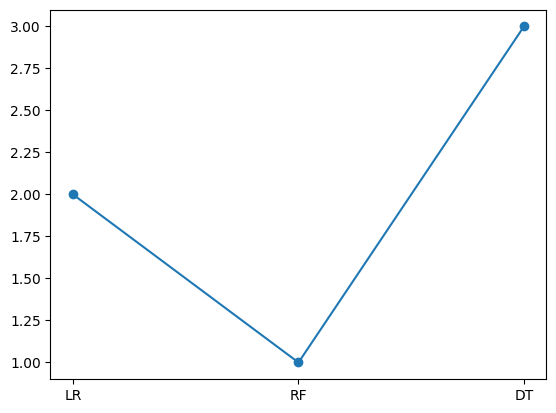

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

df = pd.read_csv('/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv')

df = df.dropna()

X = df.drop('accident_severity', axis=1)
y = df['accident_severity']

X = pd.get_dummies(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

models = {
"LR": LogisticRegression(max_iter=1000),
"RF": RandomForestClassifier(),
"DT": DecisionTreeClassifier()
}

metrics = []

for n,m in models.items():
    m.fit(X_train,y_train)
    pred=m.predict(X_test)
    metrics.append([
        n,
        accuracy_score(y_test,pred),
        f1_score(y_test,pred,average='weighted')
    ])

df_res=pd.DataFrame(metrics,columns=["Model","Accuracy","F1"])
df_res["Rank"]=df_res["Accuracy"].rank(ascending=False)

df_res.to_csv("RQ5_table.csv",index=False)

plt.figure()
plt.plot(df_res["Model"],df_res["Rank"],marker='o')
plt.savefig("RQ5_figure.pdf")
print(df_res)
